In [5]:

import torch
import torch.nn as nn
from torch.nn.init import trunc_normal_

class SwinTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=4,
        in_chans=3,
        num_classes=1000,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.1,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        use_checkpoint=False,
        fused_window_process=False,
        **kwargs,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.ape = ape
        self.patch_norm = patch_norm
        self.num_features = int(embed_dim * 2 ** (self.num_layers - 1))
        self.mlp_ratio = mlp_ratio

        # split image into non-overlapping patches
        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None,
        )
        num_patches = self.patch_embed.num_patches
        patches_resolution = self.patch_embed.patches_resolution
        self.patches_resolution = patches_resolution

        # absolute position embedding
        if self.ape:
            self.absolute_pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
            trunc_normal_(self.absolute_pos_embed, std=0.02)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = [
            x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))
        ]  # stochastic depth decay rule

        # build layers
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = BasicLayer(
                dim=int(embed_dim * 2**i_layer),
                input_resolution=(
                    patches_resolution[0] // (2**i_layer),
                    patches_resolution[1] // (2**i_layer),
                ),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=self.mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]) : sum(depths[: i_layer + 1])],
                norm_layer=norm_layer,
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None,
                use_checkpoint=use_checkpoint,
                fused_window_process=fused_window_process,
            )
            self.layers.append(layer)

        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = (
            nn.Linear(self.num_features, num_classes)
            if num_classes > 0
            else nn.Identity()
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {"absolute_pos_embed"}

    @torch.jit.ignore
    def no_weight_decay_keywords(self):
        return {"relative_position_bias_table"}

    def forward_features(self, x):
        x = self.patch_embed(x)
        if self.ape:
            x = x + self.absolute_pos_embed
        x = self.pos_drop(x)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)  # B L C
        x = self.avgpool(x.transpose(1, 2))  # B C 1
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

In [6]:
class SwinTransformerBlock(nn.Module):
    r"""Swin Transformer Block.

    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resulotion.
        num_heads (int): Number of attention heads.
        window_size (int): Window size.
        shift_size (int): Shift size for SW-MSA.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float, optional): Stochastic depth rate. Default: 0.0
        act_layer (nn.Module, optional): Activation layer. Default: nn.GELU
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
        fused_window_process (bool, optional): If True, use one kernel to fused window shift & window partition for acceleration, similar for the reversed part. Default: False
    """

    def __init__(
        self,
        dim,
        input_resolution,
        num_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        fused_window_process=False,
    ):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        if min(self.input_resolution) <= self.window_size:
            # if window size is larger than input resolution, we don't partition windows
            self.shift_size = 0
            self.window_size = min(self.input_resolution)
        assert 0 <= self.shift_size < self.window_size, "shift_size must in 0-window_size"

        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(
            dim,
            window_size=to_2tuple(self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            attn_drop=attn_drop,
            proj_drop=drop,
        )

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop,
        )

        if self.shift_size > 0:
            # calculate attention mask for SW-MSA
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))  # 1 H W 1
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(
                img_mask, self.window_size
            )  # nW, window_size, window_size, 1
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(
                attn_mask == 0, float(0.0)
            )
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)
        self.fused_window_process = fused_window_process

    ### New cell ###
    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            if not self.fused_window_process:
                shifted_x = torch.roll(
                    x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2)
                )
                # partition windows
                x_windows = window_partition(
                    shifted_x, self.window_size
                )  # nW*B, window_size, window_size, C
            else:
                x_windows = WindowProcess.apply(
                    x, B, H, W, C, -self.shift_size, self.window_size
                )
        else:
            shifted_x = x
            # partition windows
            x_windows = window_partition(
                shifted_x, self.window_size
            )  # nW*B, window_size, window_size, C

        x_windows = x_windows.view(
            -1, self.window_size * self.window_size, C
        )  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(
            x_windows, mask=self.attn_mask
        )  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)

        # reverse cyclic shift
        if self.shift_size > 0:
            if not self.fused_window_process:
                shifted_x = window_reverse(
                    attn_windows, self.window_size, H, W
                )  # B H' W' C
                x = torch.roll(
                    shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2)
                )
            else:
                x = WindowProcessReverse.apply(
                    attn_windows, B, H, W, C, self.shift_size, self.window_size
                )
        else:
            shifted_x = window_reverse(attn_windows, self.window_size, H, W)  # B H' W' C
            x = shifted_x
        x = x.view(B, H * W, C)
        x = shortcut + self.drop_path(x)

        # Feed-forward network (FFN)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

In [7]:
class PatchMerging(nn.Module):
    r"""Patch Merging Layer.

    Args:
        input_resolution (tuple[int]): Resolution of input feature.
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """

    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        assert H % 2 == 0 and W % 2 == 0, f"x size ({H}*{W}) are not even."

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x

In [8]:
from datasets import load_dataset
from transformers import AutoImageProcessor, SwinForImageClassification
import torch

model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)
image_processor = AutoImageProcessor.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)

dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

inputs = image_processor(image, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits

predicted_label_id = logits.argmax(-1).item()
predicted_label_text = model.config.id2label[predicted_label_id]

print(predicted_label_text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

cats_image.jpeg:   0%|          | 0.00/173k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1 [00:00<?, ? examples/s]

tabby, tabby cat


In [9]:
from datasets import load_dataset
from transformers import AutoImageProcessor, SwinForImageClassification
import torch

model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)
image_processor = AutoImageProcessor.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)

dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

inputs = image_processor(image, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits

predicted_label_id = logits.argmax(-1).item()
predicted_label_text = model.config.id2label[predicted_label_id]

print(predicted_label_text)

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

tabby, tabby cat


In [10]:
from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from einops.layers.torch import Rearrange
def _build_projection(self, dim_in, dim_out, kernel_size, padding, stride, method):
    if method == "dw_bn":
        proj = nn.Sequential(
            OrderedDict(
                [
                    (
                        "conv",
                        nn.Conv2d(
                            dim_in,
                            dim_in,
                            kernel_size=kernel_size,
                            padding=padding,
                            stride=stride,
                            bias=False,
                            groups=dim_in,
                        ),
                    ),
                    ("bn", nn.BatchNorm2d(dim_in)),
                    ("rearrage", Rearrange("b c h w -> b (h w) c")),
                ]
            )
        )
    elif method == "avg":
        proj = nn.Sequential(
            OrderedDict(
                [
                    (
                        "avg",
                        nn.AvgPool2d(
                            kernel_size=kernel_size,
                            padding=padding,
                            stride=stride,
                            ceil_mode=True,
                        ),
                    ),
                    ("rearrage", Rearrange("b c h w -> b (h w) c")),
                ]
            )
        )
    elif method == "linear":
        proj = None
    else:
        raise ValueError("Unknown method ({})".format(method))

    return proj

In [11]:
class ConvEmbed(nn.Module):
    def __init__(
        self, patch_size=7, in_chans=3, embed_dim=64, stride=4, padding=2, norm_layer=None
    ):
        super().__init__()
        patch_size = to_2tuple(patch_size)
        self.patch_size = patch_size

        self.proj = nn.Conv2d(
            in_chans, embed_dim, kernel_size=patch_size, stride=stride, padding=padding
        )
        self.norm = norm_layer(embed_dim) if norm_layer else None

    def forward(self, x):
        x = self.proj(x)

        B, C, H, W = x.shape
        x = rearrange(x, "b c h w -> b (h w) c")
        if self.norm:
            x = self.norm(x)
        x = rearrange(x, "b (h w) c -> b c h w", h=H, w=W)

        return x

In [12]:
class VisionTransformer(nn.Module):
    """Vision Transformer with support for patch or hybrid CNN input stage"""

    def __init__(
        self,
        patch_size=16,
        patch_stride=16,
        patch_padding=0,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        init="trunc_norm",
        **kwargs,
    ):
        super().__init__()
        self.num_features = self.embed_dim = embed_dim

        self.rearrage = None

        self.patch_embed = ConvEmbed(
            patch_size=patch_size,
            in_chans=in_chans,
            stride=patch_stride,
            padding=patch_padding,
            embed_dim=embed_dim,
            norm_layer=norm_layer,
        )

        with_cls_token = kwargs["with_cls_token"]
        if with_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        else:
            self.cls_token = None

        self.pos_drop = nn.Dropout(p=drop_rate)
        dpr = [
            x.item() for x in torch.linspace(0, drop_path_rate, depth)
        ]  # stochastic depth decay rule

        blocks = []
        for j in range(depth):
            blocks.append(
                Block(
                    dim_in=embed_dim,
                    dim_out=embed_dim,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    qkv_bias=qkv_bias,
                    drop=drop_rate,
                    attn_drop=attn_drop_rate,
                    drop_path=dpr[j],
                    act_layer=act_layer,
                    norm_layer=norm_layer,
                    **kwargs,
                )
            )
        self.blocks = nn.ModuleList(blocks)

        if self.cls_token is not None:
            trunc_normal_(self.cls_token, std=0.02)

        if init == "xavier":
            self.apply(self._init_weights_xavier)
        else:
            self.apply(self._init_weights_trunc_normal)

        def forward(self, x):
            x = self.patch_embed(x)
            B, C, H, W = x.size()

            x = rearrange(x, "b c h w -> b (h w) c")

            cls_tokens = None
            if self.cls_token is not None:
                cls_tokens = self.cls_token.expand(B, -1, -1)
                x = torch.cat((cls_tokens, x), dim=1)

            x = self.pos_drop(x)

            for i, blk in enumerate(self.blocks):
                x = blk(x, H, W)

            if self.cls_token is not None:
                cls_tokens, x = torch.split(x, [1, H * W], 1)
            x = rearrange(x, "b (h w) c -> b c h w", h=H, w=W)

            return x, cls_tokens

In [14]:
class ConvolutionalVisionTransformer(nn.Module):
    def __init__(
        self,
        in_chans=3,
        num_classes=1000,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        init="trunc_norm",
        spec=None,
    ):
        super().__init__()
        self.num_classes = num_classes

        self.num_stages = spec["NUM_STAGES"]
        for i in range(self.num_stages):
            kwargs = {
                "patch_size": spec["PATCH_SIZE"][i],
                "patch_stride": spec["PATCH_STRIDE"][i],
                "patch_padding": spec["PATCH_PADDING"][i],
                "embed_dim": spec["DIM_EMBED"][i],
                "depth": spec["DEPTH"][i],
                "num_heads": spec["NUM_HEADS"][i],
                "mlp_ratio": spec["MLP_RATIO"][i],
                "qkv_bias": spec["QKV_BIAS"][i],
                "drop_rate": spec["DROP_RATE"][i],
                "attn_drop_rate": spec["ATTN_DROP_RATE"][i],
                "drop_path_rate": spec["DROP_PATH_RATE"][i],
                "with_cls_token": spec["CLS_TOKEN"][i],
                "method": spec["QKV_PROJ_METHOD"][i],
                "kernel_size": spec["KERNEL_QKV"][i],
                "padding_q": spec["PADDING_Q"][i],
                "padding_kv": spec["PADDING_KV"][i],
                "stride_kv": spec["STRIDE_KV"][i],
                "stride_q": spec["STRIDE_Q"][i],
            }

            stage = VisionTransformer(
                in_chans=in_chans,
                init=init,
                act_layer=act_layer,
                norm_layer=norm_layer,
                **kwargs,
            )
            setattr(self, f"stage{i}", stage)

            in_chans = spec["DIM_EMBED"][i]

        dim_embed = spec["DIM_EMBED"][-1]
        self.norm = norm_layer(dim_embed)
        self.cls_token = spec["CLS_TOKEN"][-1]

        # Classifier head
        self.head = (
            nn.Linear(dim_embed, num_classes) if num_classes > 0 else nn.Identity()
        )
        trunc_normal_(self.head.weight, std=0.02)

    def forward_features(self, x):
        for i in range(self.num_stages):
            x, cls_tokens = getattr(self, f"stage{i}")(x)

        if self.cls_token:
            x = self.norm(cls_tokens)
            x = torch.squeeze(x)
        else:
            x = rearrange(x, "b c h w -> b (h w) c")
            x = self.norm(x)
            x = torch.mean(x, dim=1)

        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)

        return x

In [18]:
pip install transformers

In [27]:
from transformers import AutoImageProcessor, MobileViTV2ForImageClassification
from datasets import load_dataset
from PIL import Image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

image_processor = AutoImageProcessor.from_pretrained(
    "apple/mobilevitv2-1.0-imagenet1k-256"
)
model = MobileViTV2ForImageClassification.from_pretrained(
    "apple/mobilevitv2-1.0-imagenet1k-256"
)

inputs = image_processor(image, return_tensors="pt")

logits = model(**inputs).logits

# model predicts one of the 1000 ImageNet classes
predicted_label = logits.argmax(-1).item()
print(model.config.id2label[predicted_label])

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.8k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/19.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

tabby, tabby cat


In [38]:
from datasets import load_dataset

dataset = load_dataset("anindya64/hardhat")
dataset

README.md:   0%|          | 0.00/872 [00:00<?, ?B/s]

data/train-00000-of-00001-3e0d95da2811af(…):   0%|          | 0.00/200M [00:00<?, ?B/s]

data/test-00000-of-00001-9fc2e7e45a21ae4(…):   0%|          | 0.00/66.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1766 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 5297
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 1766
    })
})

In [39]:
train_dataset = dataset["train"]
test_dataset = dataset["test"]

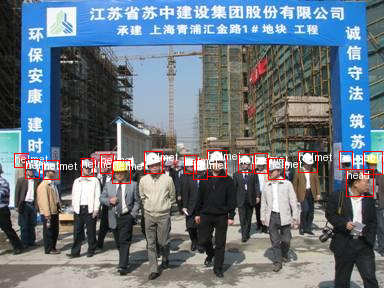

In [40]:
import numpy as np
from PIL import Image, ImageDraw


def draw_image_from_idx(dataset, idx):
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample["objects"]
    draw = ImageDraw.Draw(image)
    width, height = sample["width"], sample["height"]

    for i in range(len(annotations["id"])):
        box = annotations["bbox"][i]
        class_idx = annotations["id"][i]
        x, y, w, h = tuple(box)
        if max(box) > 1.0:
            x1, y1 = int(x), int(y)
            x2, y2 = int(x + w), int(y + h)
        else:
            x1 = int(x * width)
            y1 = int(y * height)
            x2 = int((x + w) * width)
            y2 = int((y + h) * height)
        draw.rectangle((x1, y1, x2, y2), outline="red", width=1)
        draw.text((x1, y1), annotations["category"][i], fill="white")
    return image


draw_image_from_idx(dataset=train_dataset, idx=10)

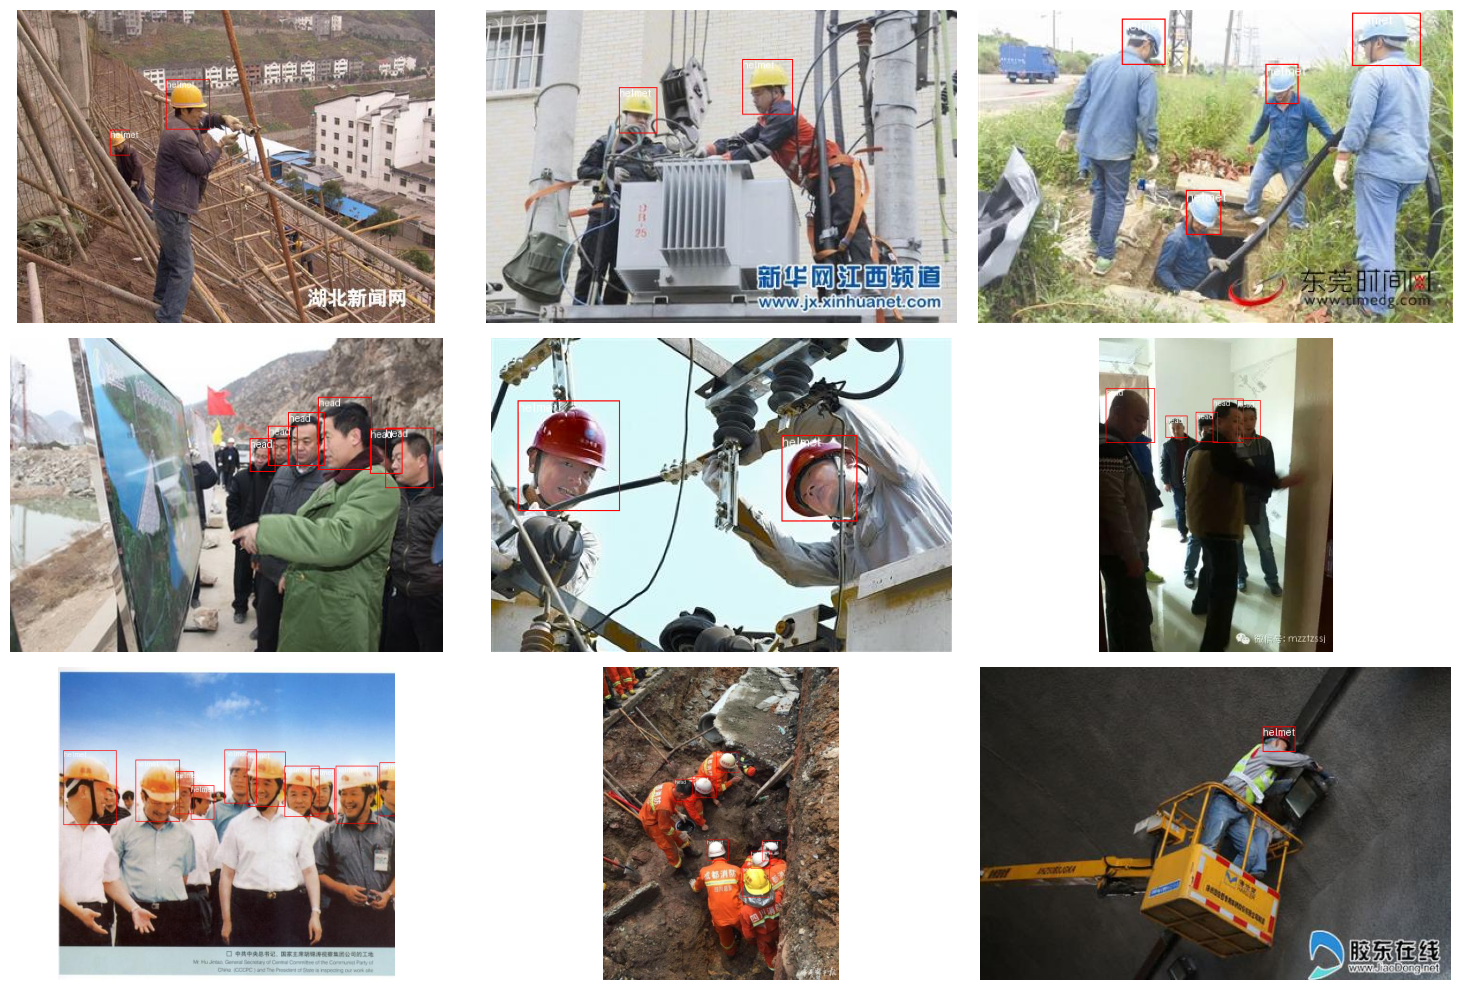

In [41]:
import matplotlib.pyplot as plt


def plot_images(dataset, indices):
    """
    Plot images and their annotations.
    """
    num_rows = len(indices) // 3
    num_cols = 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    for i, idx in enumerate(indices):
        row = i // num_cols
        col = i % num_cols

        # Draw image
        image = draw_image_from_idx(dataset, idx)

        # Display image on the corresponding subplot
        axes[row, col].imshow(image)
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


# Now use the function to plot images

plot_images(train_dataset, range(9))

In [42]:
from transformers import AutoImageProcessor

checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

In [43]:
import albumentations
import numpy as np
import torch

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)

In [44]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

In [45]:
# transforming a batch

def transform_aug_ann(examples):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["id"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

In [46]:
# transforming a batch

def transform_aug_ann(examples):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["id"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

In [47]:
# Apply transformations for both train and test dataset

train_dataset_transformed = train_dataset.with_transform(transform_aug_ann)
test_dataset_transformed = test_dataset.with_transform(transform_aug_ann)

In [48]:
train_dataset_transformed[0]

{'pixel_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'pixel_values': tensor([[[ 0.3481,  0.3481,  0.3481,  ...,  0.1254, -0.0458, -0.1657],
          [ 0.3481,  0.3481,  0.3481,  ...,  0.1254, -0.0629, -0.1828],
          [ 0.3481,  0.3481,  0.3309,  ...,  0.1083, -0.0801, -0.1999],
          ...,
          [-0.0629, -0.1486, -0.2856,  ..., -0.3541, -0.4226, -0.4739],
          [-0.0629, -0.1657, -0.3027,  ..., -0.3883, -0.4568, -0.5082],
          [-0.0629, -0.1657, -0.3027,  ..., -0.4054, -0.4911, -0.5424]],
 
         [[ 0.4153,  0.4153,  0.4153,  ...,  0.6254,  0.4328,  0.2927],
          [ 0.4153,  0.4153,  0.4153,  ...,  0.6078,  0.3978,  0.2577],
          [ 0.4153,  0.4153,  0.3978,  ...,  0.5903,  0.3627,  0.2227],
          ...,
          [ 0.4328,  0.3102,  0.1352,  ..., -0.0224, -0.0924, -

In [49]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

In [50]:
from transformers import AutoModelForObjectDetection

id2label = {0: "head", 1: "helmet", 2: "person"}
label2id = {v: k for k, v in id2label.items()}


model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

config.json:   0%|          | 0.00/4.38k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50-dc5
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |         

In [51]:
from huggingface_hub import notebook_login

notebook_login()

In [1]:
import torch
from torch import nn
from torchvision.models import resnet50


class DETR(nn.Module):
    def __init__(
        self, num_classes, hidden_dim, nheads, num_encoder_layers, num_decoder_layers
    ):
        super().__init__()
        self.backbone = nn.Sequential(*list(resnet50(pretrained=True).children())[:-2])
        self.conv = nn.Conv2d(2048, hidden_dim, 1)
        self.transformer = nn.Transformer(
            hidden_dim, nheads, num_encoder_layers, num_decoder_layers
        )
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)
        self.linear_bbox = nn.Linear(hidden_dim, 4)
        self.query_pos = nn.Parameter(torch.rand(100, hidden_dim))
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))

    def forward(self, inputs):
        x = self.backbone(inputs)
        h = self.conv(x)
        H, W = h.shape[-2:]
        pos = (
            torch.cat(
                [
                    self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),
                    self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),
                ],
                dim=-1,
            )
            .flatten(0, 1)
            .unsqueeze(1)
        )
        h = self.transformer(
            pos + h.flatten(2).permute(2, 0, 1), self.query_pos.unsqueeze(1)
        )
        return self.linear_class(h), self.linear_bbox(h).sigmoid()

In [2]:
from transformers import pipeline
from PIL import Image
import requests

segmentation = pipeline("image-segmentation", "facebook/maskformer-swin-base-coco")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

results = segmentation(inputs=image, subtask="panoptic")
results

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/10.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/411M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/648 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

[transformers] `label_ids_to_fuse` unset. No instance will be fused.


[{'score': 0.993197,
  'label': 'remote',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.997852,
  'label': 'cat',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.998006,
  'label': 'remote',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.997469,
  'label': 'cat',
  'mask': <PIL.Image.Image image mode=L size=640x480>}]

In [3]:
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt


def run_segmentation(image, task_type):
    """Performs image segmentation based on the given task type.

    Args:
        image (PIL.Image): The input image.
        task_type (str): The type of segmentation to perform ('semantic', 'instance', or 'panoptic').

    Returns:
        PIL.Image: The segmented image.

    Raises:
        ValueError: If the task type is invalid.
    """

    processor = OneFormerProcessor.from_pretrained(
        "shi-labs/oneformer_ade20k_dinat_large"
    )  # Load once here
    model = OneFormerForUniversalSegmentation.from_pretrained(
        "shi-labs/oneformer_ade20k_dinat_large"
    )

    if task_type == "semantic":
        inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_semantic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]

    elif task_type == "instance":
        inputs = processor(images=image, task_inputs=["instance"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_instance_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    elif task_type == "panoptic":
        inputs = processor(images=image, task_inputs=["panoptic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_panoptic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    else:
        raise ValueError(
            "Invalid task type. Choose from 'semantic', 'instance', or 'panoptic'"
        )

    return predicted_map


def show_image_comparison(image, predicted_map, segmentation_title):
    """Displays the original image and the segmented image side-by-side.

    Args:
        image (PIL.Image): The original image.
        predicted_map (PIL.Image): The segmented image.
        segmentation_title (str): The title for the segmented image.
    """

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(predicted_map)
    plt.title(segmentation_title + " Segmentation")
    plt.axis("off")
    plt.show()


url = "https://huggingface.co/datasets/shi-labs/oneformer_demo/resolve/main/ade20k.jpeg"
response = requests.get(url, stream=True)
response.raise_for_status()  # Check for HTTP errors
image = Image.open(response.raw)

task_to_run = "semantic"
predicted_map = run_segmentation(image, task_to_run)
show_image_comparison(image, predicted_map, task_to_run)


preprocessor_config.json:   0%|          | 0.00/8.71k [00:00<?, ?B/s]

ade20k_panoptic.json:   0%|          | 0.00/7.08k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/84.7k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/893M [00:00<?, ?B/s]

ImportError: 
DinatBackbone requires the natten library but it was not found in your environment. You can install it by referring to:
shi-labs.com/natten . You can also install it with pip (may take longer to build):
`pip install natten`. Please note that you may need to restart your runtime after installation.
